# NUTDTS 816 Time Series Analysis
## L03 Decomposition I: models, moving averages, classical decomposition

Lab notebook for Chapter 2 of the lecture notes. Run the setup cell first. Every code cell reproduces an example from the notes; the exercises at the end are from the chapter's self-check list.

**Instructor:** Dr Tolulope Adesina · NUTM MSc Data Science · 2026

In [2]:
# ---- Setup: run once per Colab session ----
# 1. Install the course libraries (about two minutes the first time)
!pip install -q statsmodels pmdarima statsforecast neuralforecast lightgbm arch plotly

# 2. Fetch the course data module and data snapshots from the course repository.
#    Replace REPO with your fork or the official course repository URL.
REPO = "https://github.com/toadesina/NUTDTS816_Course_Repository/raw/main"
import urllib.request, os
os.makedirs("data", exist_ok=True)
urllib.request.urlretrieve(f"{REPO}/src/tsdata.py", "tsdata.py")
DATA_FILES = ["nigeria_cpi", "nigeria_fx", "nigeria_grid", "nigeria_malaria", "nigeria_rainfall", "bonny_light", "daily_demand",
              "airpassengers", "a10", "h02", "ausbeer", "elecequip", "usmelec", "goog", "nile", "austourists", "oil", "dax", "uschange", "elecdemand"]
for f in DATA_FILES:
    urllib.request.urlretrieve(f"{REPO}/data/{f}.csv", f"data/{f}.csv")

import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 3.6), "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
import tsdata
print("Setup complete.")

Setup complete.


### 2.1 Decomposition models

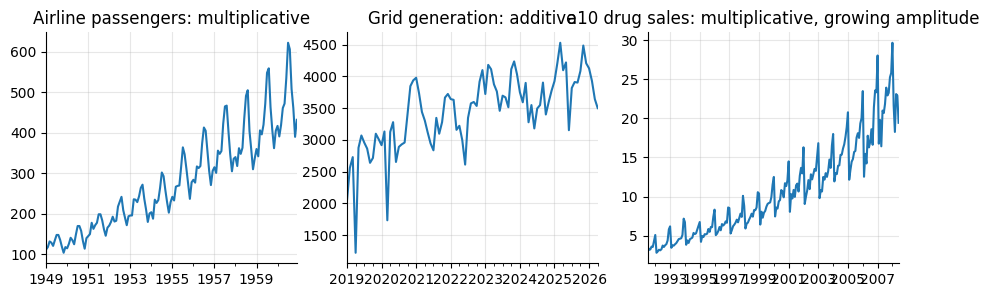

In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import tsdata
ap   = tsdata.airpassengers()     # multiplicative
grid = tsdata.nigeria_grid()      # additive (simulated)
a10  = tsdata.a10()               # monthly antidiabetic drug sales, Australia: multiplicative, strong trend
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
ap.plot(ax=axes[0], title='Airline passengers: multiplicative')
grid.plot(ax=axes[1], title='Grid generation: additive')
a10.plot(ax=axes[2], title='a10 drug sales: multiplicative, growing amplitude')
for ax in axes: ax.set_xlabel('')
_caption = 'Two multiplicative series and one additive series.'

### 2.2 Estimating the trend with moving averages

First valid trend value: 1949-07-01 | last: 1960-06-01


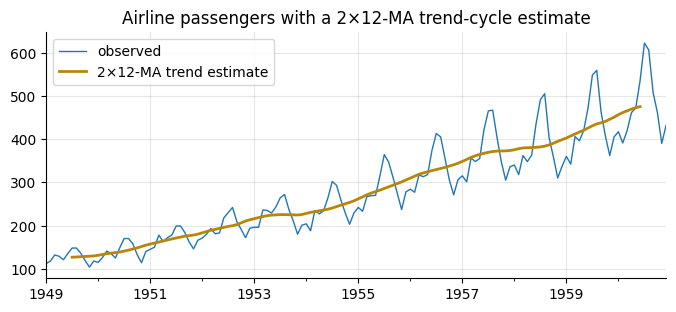

In [4]:
def centred_2xm_ma(s, m):
    """2 x m moving average (for even m) or m-MA (odd m)."""
    if m % 2 == 1:
        return s.rolling(m, center=True).mean()
    first = s.rolling(m).mean()                 # trailing m-MA
    return first.rolling(2).mean().shift(-m // 2)  # average adjacent pairs and recentre

t_hat = centred_2xm_ma(ap, 12)
ax = ap.plot(figsize=(8, 3.2), label='observed', lw=1)
t_hat.plot(ax=ax, color='#B8860B', lw=2, label='2×12-MA trend estimate')
ax.set_title('Airline passengers with a 2×12-MA trend-cycle estimate'); ax.legend(); ax.set_xlabel('')
print('First valid trend value:', t_hat.first_valid_index().date(), '| last:', t_hat.last_valid_index().date())
_caption = 'The moving average removes the annual pattern and most of the noise. Six months are lost at each end.'

### 2.3 Classical decomposition

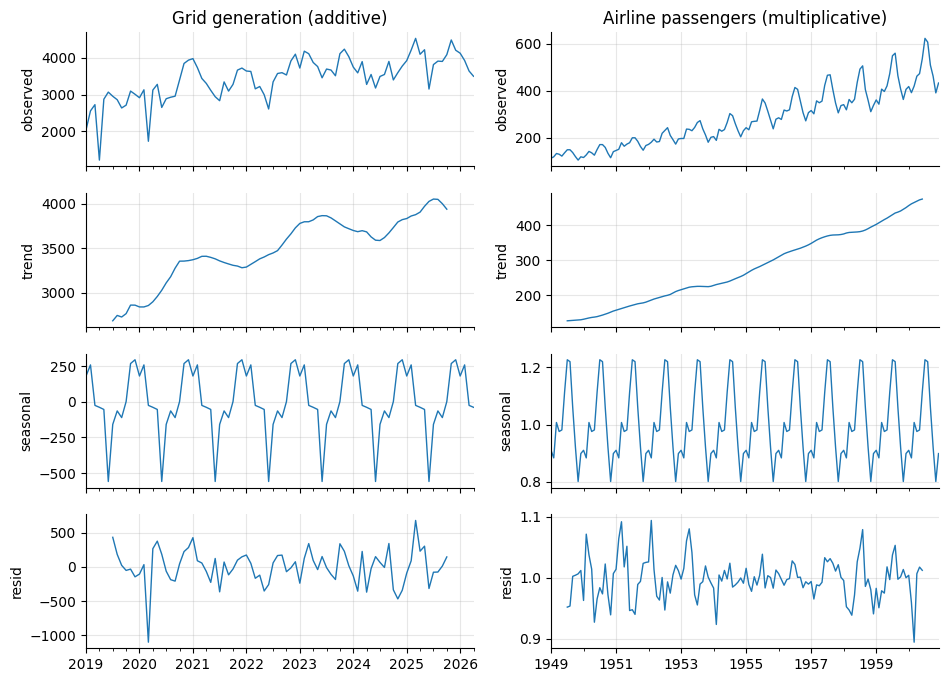

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
dec_add  = seasonal_decompose(grid, model='additive', period=12)
dec_mult = seasonal_decompose(ap,   model='multiplicative', period=12)

fig, axes = plt.subplots(4, 2, figsize=(11, 8), sharex='col')
for col, (dec, name) in enumerate([(dec_add, 'Grid generation (additive)'), (dec_mult, 'Airline passengers (multiplicative)')]):
    for row, comp in enumerate(['observed', 'trend', 'seasonal', 'resid']):
        getattr(dec, comp).plot(ax=axes[row, col], lw=1); axes[row, col].set_ylabel(comp); axes[row, col].set_xlabel('')
    axes[0, col].set_title(name)
_caption = 'Classical decomposition panels. Note the gaps at the ends of trend and remainder, and the identical seasonal pattern every year.'

In [6]:
print('Seasonal factors, airline (multiplicative), one year:')
print(dec_mult.seasonal['1950'].round(3).to_string())
print('\nSeasonal effects, grid (additive, MW), one year:')
print(dec_add.seasonal['2020'].round(0).to_string())

Seasonal factors, airline (multiplicative), one year:
date
1950-01-01    0.910
1950-02-01    0.884
1950-03-01    1.007
1950-04-01    0.976
1950-05-01    0.981
1950-06-01    1.113
1950-07-01    1.227
1950-08-01    1.220
1950-09-01    1.060
1950-10-01    0.922
1950-11-01    0.801
1950-12-01    0.899
Freq: MS

Seasonal effects, grid (additive, MW), one year:
date
2020-01-01    182.0
2020-02-01    260.0
2020-03-01    -25.0
2020-04-01    -38.0
2020-05-01    -53.0
2020-06-01   -559.0
2020-07-01   -158.0
2020-08-01    -63.0
2020-09-01   -110.0
2020-10-01      2.0
2020-11-01    269.0
2020-12-01    296.0
Freq: MS


## Exercises

1. Write out the weights of a $2 \times 4$-MA and show that each quarter receives total weight $1/4$.
2. Decompose the `ausbeer` series (quarterly beer production, course data module) with classical and STL decompositions. In which years does the seasonal pattern change, and how does STL show it while classical decomposition cannot?
3. For the simulated `nigeria_grid()` series, compare the STL seasonal component with `seasonal=7` and `seasonal=25`. Which would you use for a five-year capacity plan, and why?

#### Exercise 1

In [8]:
# Your work here
# First define a 4-MA window and a 2-MA window
ma4_weights = np.array([1/4, 1/4, 1/4, 1/4])
ma2_weights = np.array([1/2, 1/2])

In [9]:
# Combine the two moving averages to get the combined weights
combined_weights = np.convolve(ma4_weights, ma2_weights)

In [12]:
# Display the resulting weights
lags = [-3, -2, -1, 0, 1]
df_weights = pd.DataFrame({'Lag': lags, 'Weight': combined_weights})
print("2x4-MA Combined Weights:")
print(df_weights.to_string(index=False))

# Show total weight contributed across quarters
print("\nSum of middle weights (inner quarters):", sum(combined_weights[1:4]))
print("Sum of end weights (outer quarters):", combined_weights[0] + combined_weights[4])

2x4-MA Combined Weights:
 Lag  Weight
  -3   0.125
  -2   0.250
  -1   0.250
   0   0.250
   1   0.125

Sum of middle weights (inner quarters): 0.75
Sum of end weights (outer quarters): 0.25


#### Exercise 2

In [15]:
# fetch raw datasets
ausbeer = tsdata.ausbeer()      # Quarterly Australian Beer data
print(type(ausbeer), ausbeer.index.freq)
print(ausbeer.head(6))
print(ausbeer.index[:3])

<class 'pandas.core.series.Series'> <QuarterBegin: startingMonth=1>
date
1956-01-01    284
1956-04-01    213
1956-07-01    227
1956-10-01    308
1957-01-01    262
1957-04-01    228
Freq: QS-JAN, Name: beer, dtype: int64
DatetimeIndex(['1956-01-01', '1956-04-01', '1956-07-01'], dtype='datetime64[ns]', name='date', freq='QS-JAN')


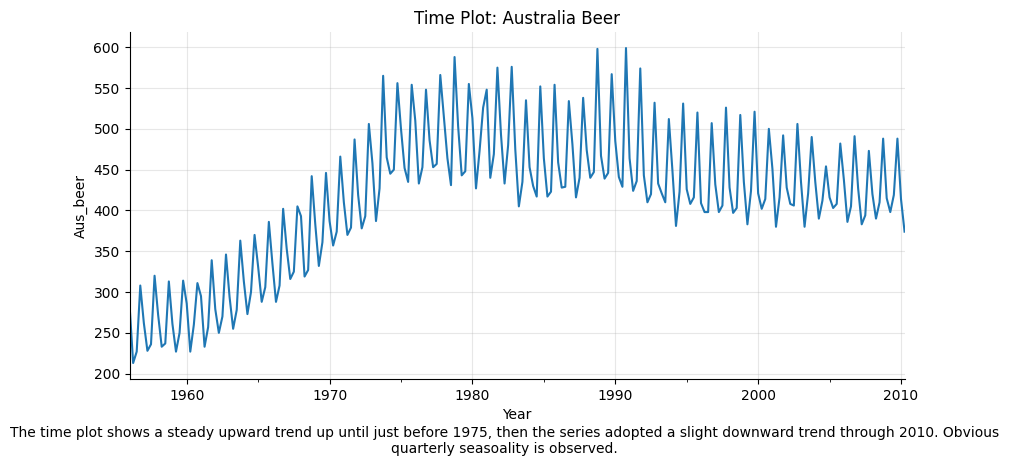

In [24]:
# Australia Beer Time Plot
plt.figure(figsize=(10, 4.5))
ausbeer.plot(title = 'Time Plot: Australia Beer', xlabel = 'Year', ylabel = 'Aus_beer')

_caption = 'The time plot shows a steady upward trend up until just before 1975, then the series adopted a slight downward trend through 2010. Obvious quarterly seasoality is observed.'
plt.figtext(0.5, -0.05, _caption, wrap= True, horizontalalignment="center", fontsize = 10)
plt.show()

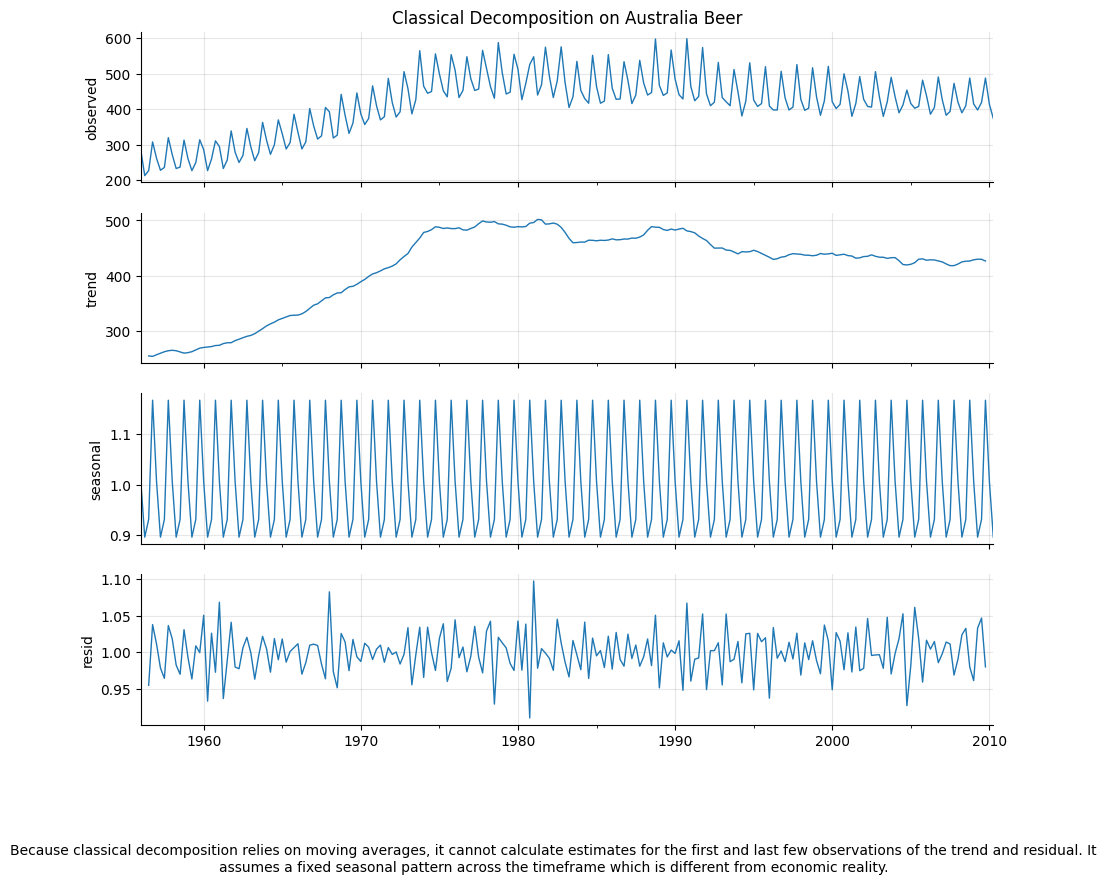

In [22]:
# Australian beer classical decomposition
from statsmodels.tsa.seasonal import seasonal_decompose     # import required decomposition library
dec_mult  = seasonal_decompose(ausbeer, model='multiplicative', period=4)
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex='col')

for row, comp in enumerate(['observed', 'trend', 'seasonal', 'resid']):     # label each component chart
    getattr(dec_mult, comp).plot(ax=axes[row], lw=1); axes[row].set_ylabel(comp); axes[row].set_xlabel('')
axes[0].set_title('Classical Decomposition on Australia Beer')

_caption = 'Because classical decomposition relies on moving averages, it cannot calculate estimates for the first and last few observations of the trend and residual. It assumes a fixed seasonal pattern across the timeframe which is different from economic reality.'
plt.figtext(0.5, -0.05, _caption, wrap=True, horizontalalignment='center', fontsize=10)
plt.show()

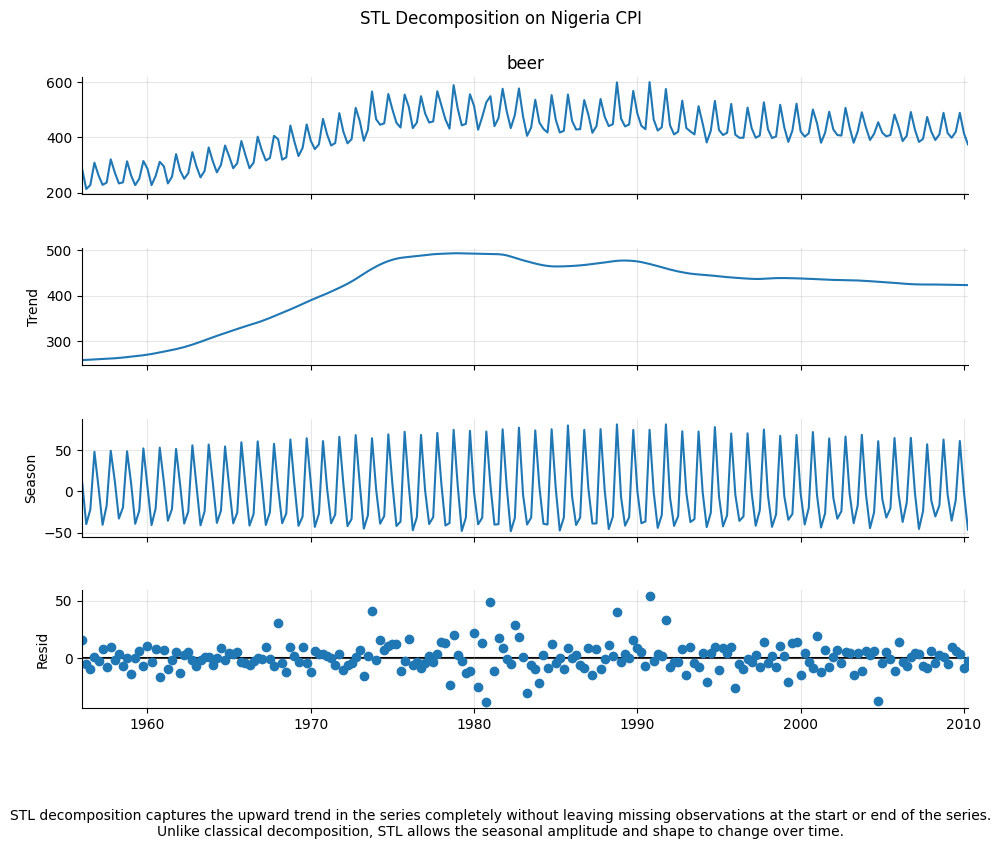

In [26]:
# Australian beer STL decomposition
from statsmodels.tsa.seasonal import STL     # import required STL library
stl_ausbeer = STL((ausbeer), period=12, seasonal=13, robust=True).fit()
fig = stl_ausbeer.plot(); fig.set_size_inches(10, 8)
fig.suptitle('STL Decomposition on Australian Beer', fontsize=12, fontweight='light')

_caption = 'STL decomposition captures the upward trend in the series completely without leaving missing observations at the start or end of the series. Unlike classical decomposition, STL allows the seasonal amplitude and shape to change over time.'
plt.figtext(0.5, -0.05, _caption, wrap=True, horizontalalignment='center', fontsize=10)
plt.show()

#### commentary
Around 1970, the seasonal amplitude increases, with the difference between the seasonal peaks and troughs becoming wider. This wider seasonal variation is then maintained for several decades, roughly through the 1970 to 1990s.

Around 1995, the seasonal amplitude begins to narrow, with the seasonal peaks and troughs becoming less pronounced. This suggests a dampening of the seasonal pattern from around the mid-1990s onward.

> How STL shows this while Classical Decomposition cannot

Classical Decomposition:
Classical decomposition assumes a fixed seasonal pattern throughout the entire series. It calculates one average seasonal effect for each quarter across the whole period. Therefore, it cannot capture the increase in seasonal variation around 1970 or the dampening after around 1995. Some of this changing seasonal variation would remain in the remainder component.
STL (Seasonal-Trend decomposition using LOESS) on the other hand uses flexible local regression (LOESS), allowing the seasonal component to change over time. In this plot, STL captures both the increase in seasonal amplitude around 1970 and the narrowing of the seasonal pattern from around 1995. This allows the remainder component to contain less unexplained seasonal variation.

#### Exercise 3

In [27]:
# fetch raw datasets
ng_grid = tsdata.nigeria_grid()     # Nigeria Grid (simulated)
print(type(ng_grid), ng_grid.index.freq)
print(ng_grid.head(6))
print(ng_grid.index[:3])

<class 'pandas.core.series.Series'> <MonthBegin>
date
2019-01-01    2043.0
2019-02-01    2559.5
2019-03-01    2728.5
2019-04-01    1222.2
2019-05-01    2876.3
2019-06-01    3069.4
Freq: MS, Name: generation_mw, dtype: float64
DatetimeIndex(['2019-01-01', '2019-02-01', '2019-03-01'], dtype='datetime64[ns]', name='date', freq='MS')


<Axes: title={'center': 'Time Plot: Nigeria Grid (simulated)'}, xlabel='Year', ylabel='Grid'>

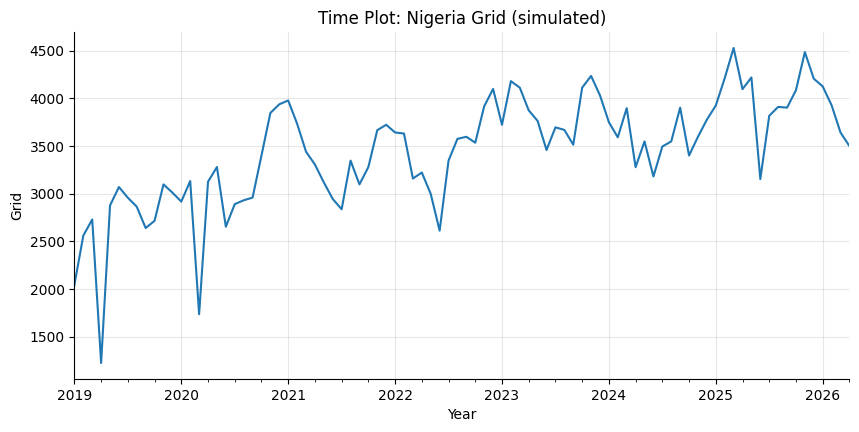

In [31]:
# Nigeria Grid (simulated) Time Plot
plt.figure(figsize=(10, 4.5))
ng_grid.plot(title = 'Time Plot: Nigeria Grid (simulated)', xlabel = 'Year', ylabel = 'Grid')


Text(0.5, 0.98, 'STL Decomposition on Nigeria Grid')

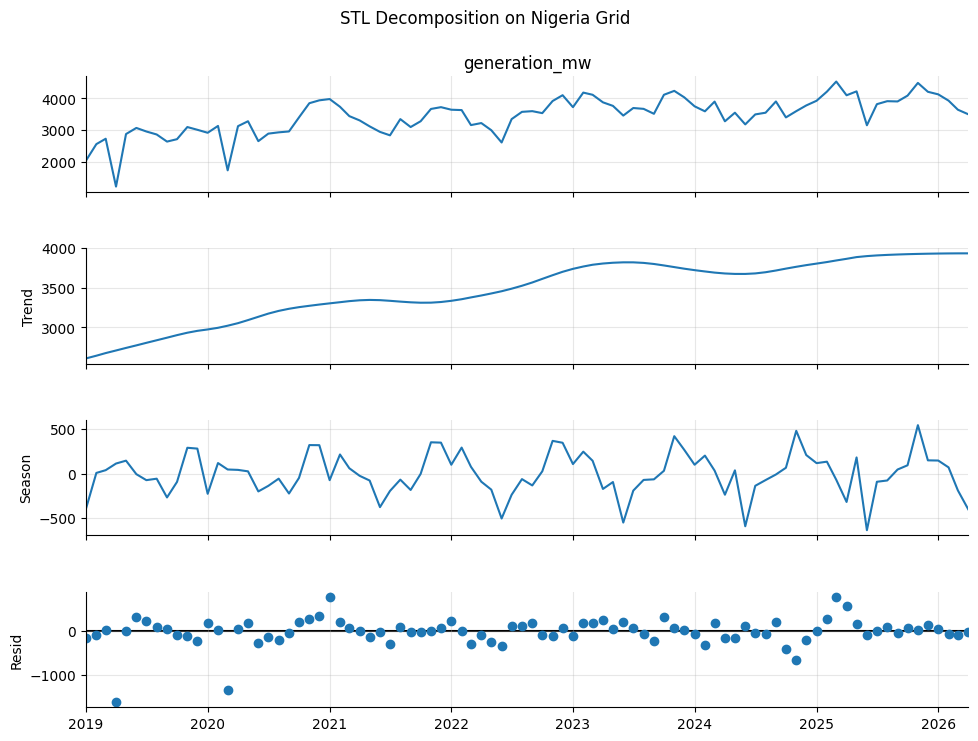

In [33]:
# Nigeria Grid STL decomposition, with seasonal=7
from statsmodels.tsa.seasonal import STL     # import required STL library
stl_ng_grid = STL((ng_grid), period=12, seasonal=7, robust=True).fit()
fig = stl_ng_grid.plot(); fig.set_size_inches(10, 8)
fig.suptitle('STL Decomposition on Nigeria Grid', fontsize=12, fontweight='light')

Text(0.5, 0.98, 'STL Decomposition on Nigeria Grid')

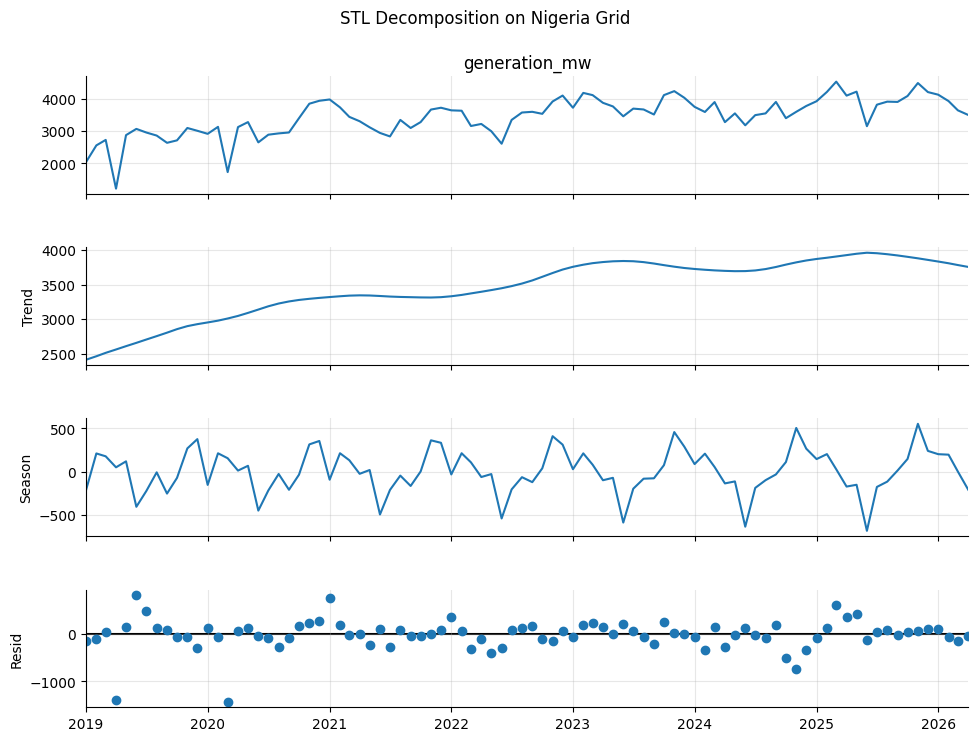

In [34]:
# Nigeria Grid STL decomposition, with seasonal=25
from statsmodels.tsa.seasonal import STL     # import required STL library
stl_ng_grid = STL((ng_grid), period=12, seasonal=25, robust=True).fit()
fig = stl_ng_grid.plot(); fig.set_size_inches(10, 8)
fig.suptitle('STL Decomposition on Nigeria Grid', fontsize=12, fontweight='light')

#### commentary

> seasonal = 7

This allows the seasonal component to change more quickly and it captures shorter-term variations in the seasonal pattern. This can be useful when you want to capture weekly or rapidly changing patterns.

> seasonal = 25

This produces a smoother and more stable seasonal component. It is less sensitive to short-term fluctuations, and focuses more on the underlying, persistent seasonal pattern rather than small local changes.


> Which would I use for a five-year capacity plan?

I would use seasonal = 25.

A five-year capacity plan is a long-term planning decision, so I would want the STL decomposition to capture the stable, underlying seasonal pattern rather than short-term fluctuations/noise. The smoother seasonal component from seasonal = 25 is therefore more appropriate.